| 函数   | 方式      |
| ---- | ------- |
| cut  | 按照区间宽度分 |
| qcut | 按照数据数量分 |

## 1.等宽分箱
score = pd.Series([55,60,63,70,75,80,82,90,95])

pd.cut(score, bins=3) #等宽分箱
### 1.1指定区间
bins = [0,60,80,100]
pd.cut(score, bins=bins)
### 1.2指定标签
pd.cut(

    score,
    
    bins=[0,60,80,100],
    
    labels=["差","中","优"]
)
## 2.等频分箱
score = pd.Series([10,20,30,40,50,60,70,80,90])

pd.qcut(score, q=3)


In [1]:
import pandas as pd

In [8]:
df1 = pd.read_csv("residents_data.csv",encoding = "GBK")
df1

,性别,居住地,年龄,工资
0,男,北京,38,18053
1,女,上海,42,9382
2,男,广州,23,6376
3,女,深圳,36,10746
4,男,杭州,20,5284
5,女,南京,34,9828
6,男,成都,33,9366
7,男,重庆,47,22820
8,男,武汉,36,16927
9,女,西安,42,11591


In [10]:
df1.groupby("年龄")["工资"].mean()

年龄
20     5284.0
23     5540.5
27     7426.0
32    10610.0
33     9366.0
34     9828.0
36    13836.5
38    18053.0
41    24117.0
42    10763.0
47    22820.0
50    69153.0
56     6391.0
59    68189.0
60    11020.0
Name: 工资, dtype: float64

评：根据年龄分组，特征不明显，也太多了，需要分箱操作

## 1.等宽分箱

In [13]:
pd.cut(
    df1.年龄, #年龄直接可以挂在df后面
    bins = 3
)

0     (33.333, 46.667]
1     (33.333, 46.667]
2      (19.96, 33.333]
3     (33.333, 46.667]
4      (19.96, 33.333]
5     (33.333, 46.667]
6      (19.96, 33.333]
7       (46.667, 60.0]
8     (33.333, 46.667]
9     (33.333, 46.667]
10    (33.333, 46.667]
11     (19.96, 33.333]
12     (19.96, 33.333]
13    (33.333, 46.667]
14      (46.667, 60.0]
15     (19.96, 33.333]
16      (46.667, 60.0]
17      (46.667, 60.0]
18      (46.667, 60.0]
19     (19.96, 33.333]
Name: 年龄, dtype: category
Categories (3, interval[float64, right]): [(19.96, 33.333] < (33.333, 46.667] < (46.667, 60.0]]

等宽分，（60-20）/3=13.33，由于是左开右闭，还要左边缩小一点，以包含20.

In [17]:
pd.cut(
    df1.年龄,
    bins = 3,
    right = False # 调整为左闭右开
)

0     [33.333, 46.667)
1     [33.333, 46.667)
2       [20.0, 33.333)
3     [33.333, 46.667)
4       [20.0, 33.333)
5     [33.333, 46.667)
6       [20.0, 33.333)
7      [46.667, 60.04)
8     [33.333, 46.667)
9     [33.333, 46.667)
10    [33.333, 46.667)
11      [20.0, 33.333)
12      [20.0, 33.333)
13    [33.333, 46.667)
14     [46.667, 60.04)
15      [20.0, 33.333)
16     [46.667, 60.04)
17     [46.667, 60.04)
18     [46.667, 60.04)
19      [20.0, 33.333)
Name: 年龄, dtype: category
Categories (3, interval[float64, left]): [[20.0, 33.333) < [33.333, 46.667) < [46.667, 60.04)]

### 1.1指定区间

In [19]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 120]
age_labels = ['儿童', '青少年', '青年', '壮年', '中年', '中老年', '老年']
pd.cut(
    df1.年龄,
    bins = age_bins,
    labels = age_labels
)

0      壮年
1      中年
2      青年
3      壮年
4     青少年
5      壮年
6      壮年
7      中年
8      壮年
9      中年
10     中年
11     青年
12     青年
13     中年
14     中年
15     壮年
16    中老年
17    中老年
18    中老年
19     壮年
Name: 年龄, dtype: category
Categories (7, str): ['儿童' < '青少年' < '青年' < '壮年' < '中年' < '中老年' < '老年']

In [20]:
# 为df1新建"年龄组"列，值为以上分组标签
df1["年龄组"] = pd.cut(
    df1.年龄,
    bins = age_bins,
    labels = age_labels
)

In [21]:
df1

,性别,居住地,年龄,工资,年龄组
0,男,北京,38,18053,壮年
1,女,上海,42,9382,中年
2,男,广州,23,6376,青年
3,女,深圳,36,10746,壮年
4,男,杭州,20,5284,青少年
5,女,南京,34,9828,壮年
6,男,成都,33,9366,壮年
7,男,重庆,47,22820,中年
8,男,武汉,36,16927,壮年
9,女,西安,42,11591,中年


In [22]:
# 对df1根据年龄组进行分组，计算各个年龄组的平均工资
df1.groupby("年龄组")["工资"].mean()

年龄组
青少年     5284.000000
青年      6169.000000
壮年     12305.714286
中年     24729.833333
中老年    28533.333333
Name: 工资, dtype: float64

# 2.层次化索引（多级索引）

在用groupby方法分组的时候，利用了一个以上的变量，会发现得到的DataFrame会出现层次化索引

In [23]:
df2 = pd.DataFrame({
    '分店编号': ['001', '002', '001', '002', '001', '002', '001', '002'],
    '时间段': ['2022Q1', '2022Q1', '2022Q1', '2022Q1', '2022Q2', '2022Q2', '2022Q2', '2022Q2'],
    '商品类别': ['生鲜食品', '生鲜食品', '休闲食品', '休闲食品', '生鲜食品', '生鲜食品', '休闲食品', '休闲食品'],
    '销售额': [1500, 2000, 3000, 2500, 1800, 2200, 3200, 2700],
    '销售数量': [105,  84, 171, 162,  67, 150,  99,  57]
})
grouped_df2 = df2.groupby(['分店编号', '时间段'])[['销售额', '销售数量']].mean()
grouped_df2

销售额   销售数量
分店编号 时间段                  
001  2022Q1  2250.0  138.0
     2022Q2  2500.0   83.0
002  2022Q1  2250.0  123.0
     2022Q2  2450.0  103.5

In [24]:
grouped_df2.loc["001"]  # 最外层索引会得到多个值

,销售额,销售数量
时间段,,
2022Q1,2250.0,138.0
2022Q2,2500.0,83.0


In [25]:
# 提取一行，可以在外层索引后，继续用内层索引继续去提取.但不能直接用内层的索引。
grouped_df2.loc["001"].loc["2022Q1"]

销售额     2250.0
销售数量     138.0
Name: 2022Q1, dtype: float64

# 3.根据条件进行筛选

In [26]:
df1

,性别,居住地,年龄,工资,年龄组
0,男,北京,38,18053,壮年
1,女,上海,42,9382,中年
2,男,广州,23,6376,青年
3,女,深圳,36,10746,壮年
4,男,杭州,20,5284,青少年
5,女,南京,34,9828,壮年
6,男,成都,33,9366,壮年
7,男,重庆,47,22820,中年
8,男,武汉,36,16927,壮年
9,女,西安,42,11591,中年


In [28]:
df1[(df1["性别"]=="男") & (df1["年龄"]<=20)]

,性别,居住地,年龄,工资,年龄组
4,男,杭州,20,5284,青少年


In [30]:
df1.query('性别 == "男" and 年龄 <=20')  # 列名不加双引号（除非有空格），字符需要加。为了区分，外层用单引号。

,性别,居住地,年龄,工资,年龄组
4,男,杭州,20,5284,青少年


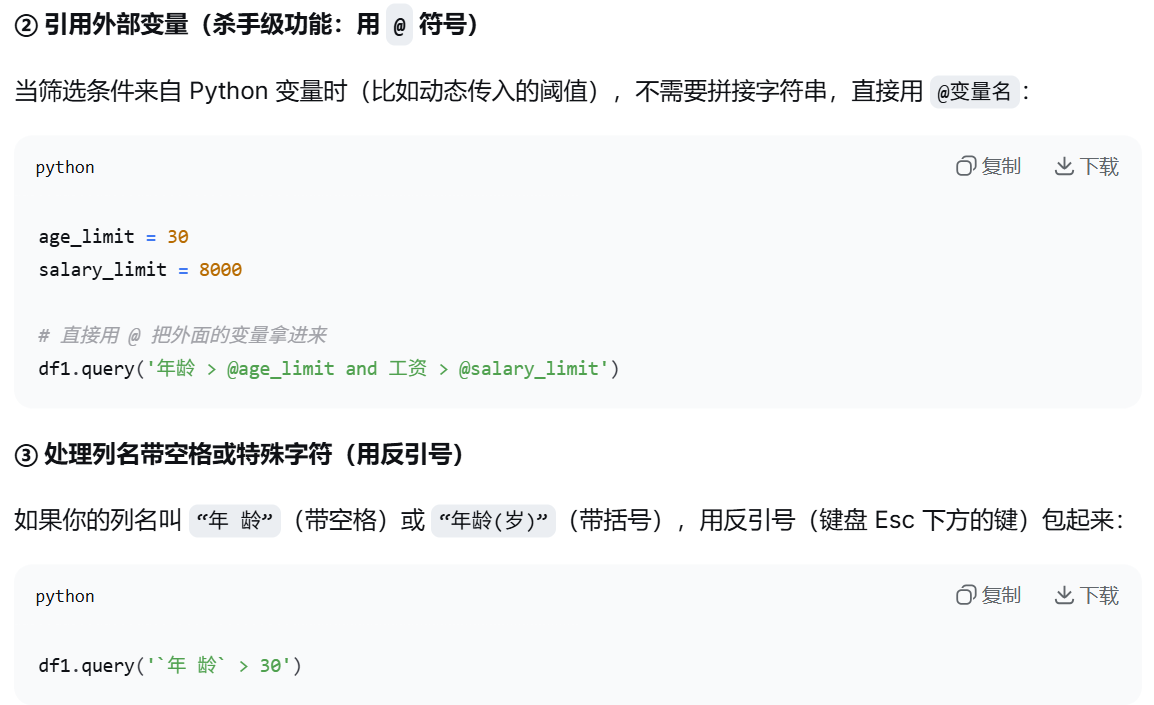